In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

In [2]:
file_path = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\Extracted features\ImgFeatures.csv"
df_features = pd.read_csv(file_path)

In [3]:
print(f"Dataset Loaded: {df_features.shape[0]} images, {df_features.shape[1]} columns.")
df_features.head()

Dataset Loaded: 3917 images, 260 columns.


,File_Name,Actual_Label,Model_Prob,Model_Pred,V_0,V_1,V_2,V_3,V_4,V_5,...,V_246,V_247,V_248,V_249,V_250,V_251,V_252,V_253,V_254,V_255
0,0.jpg,1,0.248795,1,0.000000,0.0,0.000000,1.697159,0.000000,1.86837,...,0.000000,0.000000,0.000000,10.776767,0.0,0.0,0.000000,2.536072,0.000000,0.0
1,1.jpg,1,0.528004,1,2.186334,0.0,3.379437,0.538829,1.463112,0.00000,...,1.746857,0.738651,0.000000,2.754752,0.0,0.0,0.000000,0.357644,0.000000,0.0
2,10.jpg,1,0.989365,1,6.637469,0.0,0.000000,0.000000,0.000000,0.00000,...,3.653630,0.000000,0.000000,6.645833,0.0,0.0,1.608553,0.000000,2.531080,0.0
3,100.jpg,1,0.528509,1,6.836581,0.0,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,2.709943,4.344794,0.0,0.0,2.025793,0.000000,0.844877,0.0
4,1000.jpg,1,0.577909,1,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,...,4.256838,0.000000,0.000000,6.171839,0.0,0.0,1.030482,0.000000,1.928777,0.0


In [6]:
feature_cols = [f'V_{i}' for i in range(256)]
x = df_features[feature_cols].values
metadata = df_features[['File_Name', 'Actual_Label', 'Model_Prob', 'Model_Pred']]
print(f"Ready for PCA: {x.shape[1]} features isolated.")

Ready for PCA: 256 features isolated.


In [10]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(f"New Mean (should be 0): {np.mean(x_scaled):.1f}")
print(f"New Std Dev (should be 1): {np.std(x_scaled):.1f}")

New Mean (should be 0): -0.0
New Std Dev (should be 1): 1.0


Covariance Matrix Shape: (256, 256)
This matrix shows the relationship between all 256 facial features.


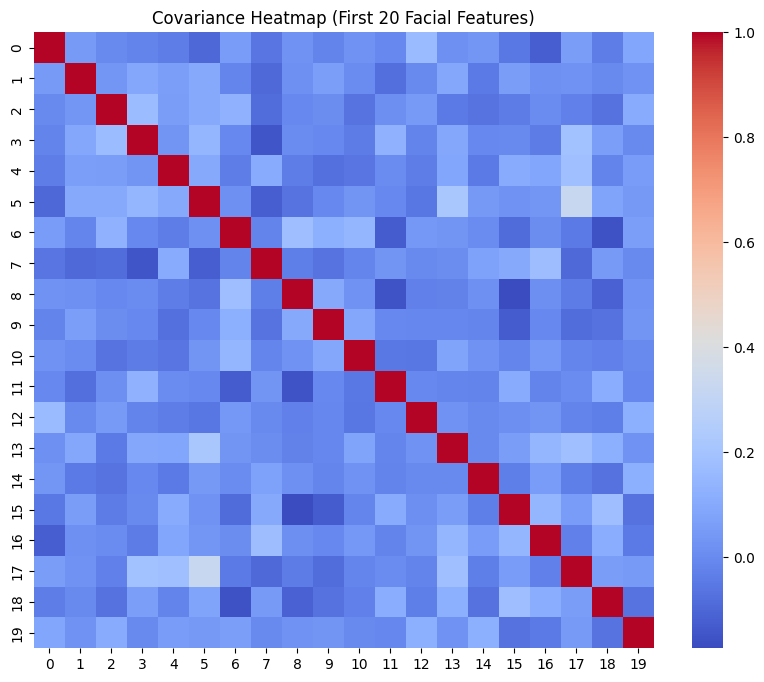

In [13]:
cov_matrix = np.cov(x_scaled.T)
print(f"Covariance Matrix Shape: {cov_matrix.shape}")
print("This matrix shows the relationship between all 256 facial features.")

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix[:20, :20], annot=False, cmap='coolwarm')
plt.title("Covariance Heatmap (First 20 Facial Features)")
plt.show()

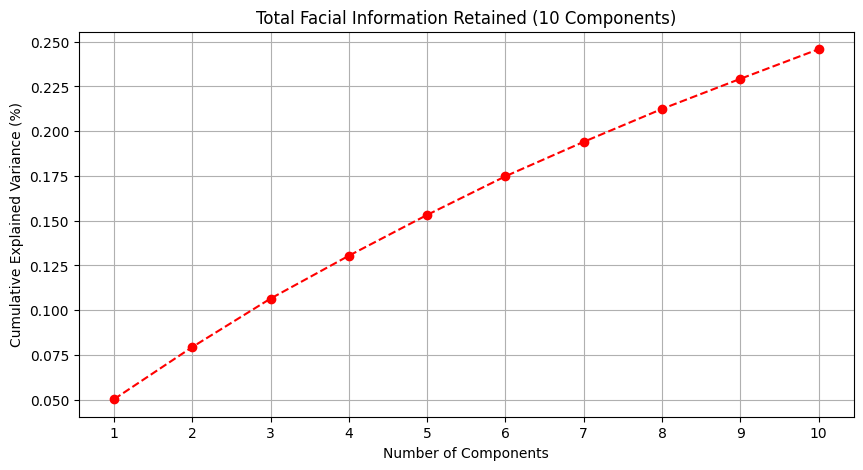

Total information captured by 10 components: 24.58%


In [37]:
# 1. Set your desired components
n_comp = 10

# 2. Run PCA
pca = PCA(n_components=n_comp)
pca_data = pca.fit_transform(x_scaled)

# 3. Create column names that match the number (20)
pca_cols = [f'PC_{i+1}' for i in range(n_comp)]
df_pca = pd.DataFrame(data=pca_data, columns=pca_cols)

# 4. Calculate variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 5. Plot using the full range (1 to 20)
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_comp + 1), cumulative_variance, marker='o', linestyle='--', color='red')
plt.title(f'Total Facial Information Retained ({n_comp} Components)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.xticks(range(1, n_comp + 1)) # Shows all numbers on x-axis
plt.grid(True)
plt.show()

print(f"Total information captured by {n_comp} components: {cumulative_variance[-1]*100:.2f}%")

In [33]:
pca_30 = PCA(n_components=30)
pca_30.fit(x_scaled)
print(f"Information with 30 components: {np.sum(pca_30.explained_variance_ratio_)*100:.2f}%")

Information with 30 components: 44.01%


In [38]:
# 1. Initialize PCA for exactly 10 components
n_components = 10
pca = PCA(n_components=n_components)

# 2. Perform the actual transformation
# This maps your 256 standardized features onto the 10 new axes
pca_features = pca.fit_transform(x_scaled)

# 3. Create a clean DataFrame for the results
pca_cols = [f'PC_{i+1}' for i in range(n_components)]
df_pca_results = pd.DataFrame(data=pca_features, columns=pca_cols)

print(f"Step 4 Complete: Your facial features are now compressed into {n_components} columns.")
print(df_pca_results.head())

Step 4 Complete: Your facial features are now compressed into 10 columns.
       PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
0 -1.030174 -0.349311  2.358678 -0.373066 -0.437917 -0.578731  2.863434   
1  2.495959  0.343507  2.045014  0.804738 -0.779244  3.691546  2.917721   
2  3.650792 -3.275067 -0.964694 -1.392416  1.651231 -2.810213 -0.300099   
3  1.513595 -0.106864 -1.310592  0.746829  0.321666 -1.547971  0.315658   
4  0.469297 -4.769705  1.412992 -0.721934 -0.051565 -1.462640 -1.696543   

       PC_8      PC_9     PC_10  
0 -2.284047  0.147737  1.721286  
1 -3.148240 -1.125745  1.115428  
2  0.856757 -4.238728 -0.567283  
3  3.231255 -0.973697 -3.088895  
4  2.895949 -0.854715  1.617748  


In [39]:
# 1. Initialize PCA for exactly 10 components
pca = PCA(n_components=n_components)

# 2. Perform the transformation (The "Squeeze")
pca_features = pca.fit_transform(x_scaled)

# 3. Create the 10-column DataFrame (PC1...PC10)
pca_cols = [f'PC_{i+1}' for i in range(n_components)]
df_pca_results = pd.DataFrame(data=pca_features, columns=pca_cols)

# 4. RE-ATTACH Actual_Label and Model_Prob (The "Glue")
final_master_df = pd.concat([metadata.reset_index(drop=True), df_pca_results], axis=1)

print("Mapping Complete! Your data is now in the 10-column PC format with labels.")
print(final_master_df.head())

Mapping Complete! Your data is now in the 10-column PC format with labels.
  File_Name  Actual_Label  Model_Prob  Model_Pred      PC_1      PC_2  \
0     0.jpg             1    0.248795           1 -1.030174 -0.349311   
1     1.jpg             1    0.528004           1  2.495959  0.343507   
2    10.jpg             1    0.989365           1  3.650792 -3.275067   
3   100.jpg             1    0.528509           1  1.513595 -0.106864   
4  1000.jpg             1    0.577909           1  0.469297 -4.769705   

       PC_3      PC_4      PC_5      PC_6      PC_7      PC_8      PC_9  \
0  2.358678 -0.373066 -0.437917 -0.578731  2.863434 -2.284047  0.147737   
1  2.045014  0.804738 -0.779244  3.691546  2.917721 -3.148240 -1.125745   
2 -0.964694 -1.392416  1.651231 -2.810213 -0.300099  0.856757 -4.238728   
3 -1.310592  0.746829  0.321666 -1.547971  0.315658  3.231255 -0.973697   
4  1.412992 -0.721934 -0.051565 -1.462640 -1.696543  2.895949 -0.854715   

      PC_10  
0  1.721286  
1  1.11

In [40]:
# Create a "Loading Matrix"
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC_{i+1}' for i in range(10)], 
    index=[f'V_{i}' for i in range(256)]
)

# See which original features are the most important for PC_1
top_features_for_pc1 = loadings['PC_1'].abs().sort_values(ascending=False)
print("Top 5 Original Features contributing to PC_1:")
print(top_features_for_pc1.head(5))

Top 5 Original Features contributing to PC_1:
V_99     0.152581
V_26     0.146172
V_249    0.133034
V_49     0.132348
V_199    0.131456
Name: PC_1, dtype: float64


Top 10 Most Powerful Original Features (by Variance):
1. Feature V_90: Variance = 1.0000
2. Feature V_253: Variance = 1.0000
3. Feature V_174: Variance = 1.0000
4. Feature V_10: Variance = 1.0000
5. Feature V_68: Variance = 1.0000
6. Feature V_185: Variance = 1.0000
7. Feature V_169: Variance = 1.0000
8. Feature V_85: Variance = 1.0000
9. Feature V_172: Variance = 1.0000
10. Feature V_81: Variance = 1.0000


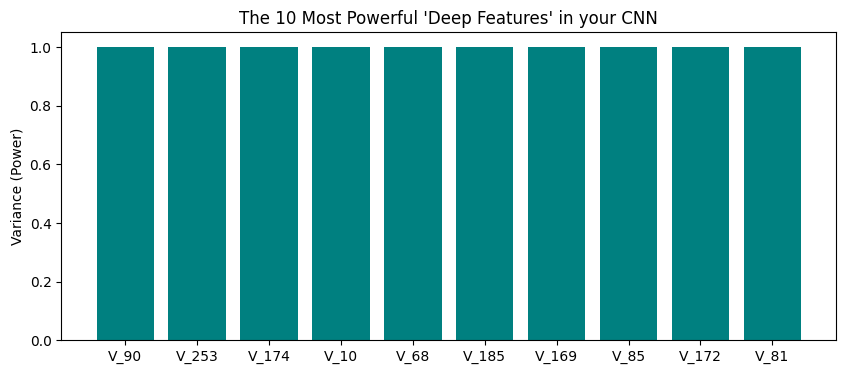

In [41]:
# 1. Calculate the variance of each original 256 feature
# (Using x_scaled because it's already normalized)
v_variances = np.var(x_scaled, axis=0)

# 2. Get indices of the top 10 most "active" features
top_indices = np.argsort(v_variances)[-10:][::-1]

print("Top 10 Most Powerful Original Features (by Variance):")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. Feature V_{idx}: Variance = {v_variances[idx]:.4f}")

# 3. Plotting the 'Feature Importance'
plt.figure(figsize=(10, 4))
plt.bar(range(len(top_indices)), v_variances[top_indices], color='teal')
plt.xticks(range(len(top_indices)), [f'V_{i}' for i in top_indices])
plt.title("The 10 Most Powerful 'Deep Features' in your CNN")
plt.ylabel("Variance (Power)")
plt.show()

In [42]:
n_comp = 10
pca = PCA(n_components=n_comp)
pca_features = pca.fit_transform(x_scaled)

# 2. Create the column names
pc_cols = [f'PC_{i+1}' for i in range(n_comp)]
df_pc = pd.DataFrame(data=pca_features, columns=pc_cols)

# 3. Merge with Metadata (Filenames and Labels)
# We reset the index to ensure row 1 of metadata matches row 1 of PCA
master_facial_df = pd.concat([metadata.reset_index(drop=True), df_pc], axis=1)

# 4. Save to CSV
master_facial_df.to_csv("Final_Facial_Features_10PC.csv", index=False)

print("SUCCESS: Your facial master file is saved!")
print(f"Total Columns: {len(master_facial_df.columns)}")
print(master_facial_df.head())

SUCCESS: Your facial master file is saved!
Total Columns: 14
  File_Name  Actual_Label  Model_Prob  Model_Pred      PC_1      PC_2  \
0     0.jpg             1    0.248795           1 -1.030174 -0.349311   
1     1.jpg             1    0.528004           1  2.495959  0.343507   
2    10.jpg             1    0.989365           1  3.650792 -3.275067   
3   100.jpg             1    0.528509           1  1.513595 -0.106864   
4  1000.jpg             1    0.577909           1  0.469297 -4.769705   

       PC_3      PC_4      PC_5      PC_6      PC_7      PC_8      PC_9  \
0  2.358678 -0.373066 -0.437917 -0.578731  2.863434 -2.284047  0.147737   
1  2.045014  0.804738 -0.779244  3.691546  2.917721 -3.148240 -1.125745   
2 -0.964694 -1.392416  1.651231 -2.810213 -0.300099  0.856757 -4.238728   
3 -1.310592  0.746829  0.321666 -1.547971  0.315658  3.231255 -0.973697   
4  1.412992 -0.721934 -0.051565 -1.462640 -1.696543  2.895949 -0.854715   

      PC_10  
0  1.721286  
1  1.115428  
2 -0.56

In [44]:
# Define the target path
save_path = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\Extracted features\Extracted0.csv"

# Create the directory if it doesn't exist (safety check)
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the master_facial_df to that specific location
master_facial_df.to_csv(save_path, index=False)

print(f"SUCCESS: Dataset saved to {save_path}")

SUCCESS: Dataset saved to C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\Extracted features\Extracted0.csv
